In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')
scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    dataset_name='kang_15K_pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True
)

scarf.fetch_dataset(
    dataset_name='kang_14K_ifnb-pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True
)

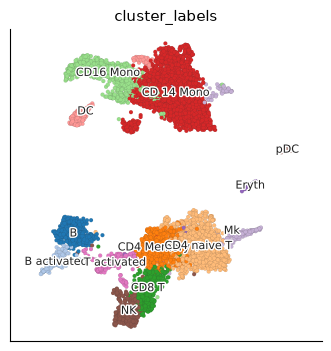

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [3]:
# Control/untreated PBMC data
ds_ctrl = scarf.DataStore(
    'scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr',
    nthreads=4
)

splt.embedding(
    ds_ctrl,
    layout_key='RNA_UMAP',
    color_by='cluster_labels',
)

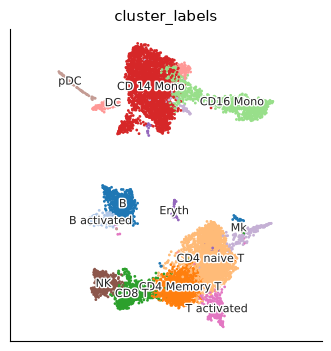

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [4]:
# Interferon beta stimulated PBMC data
ds_stim = scarf.DataStore(
    'scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr',
    nthreads=4
)

splt.embedding(
    ds_stim,
    layout_key='RNA_UMAP',
    color_by='cluster_labels',
)

In [5]:
ds_ctrl.run_mapping(
    target_assay=ds_stim.RNA,
    target_name='stim',
    target_feat_key='hvgs_ctrl',
    save_k=5
)

Target cluster CD 14 Mono


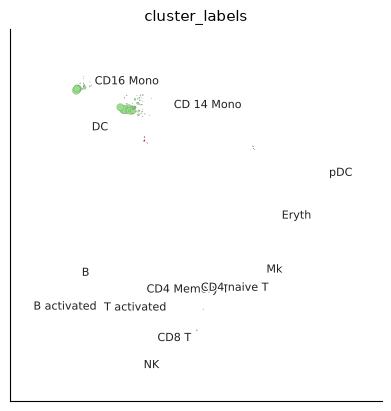

Target cluster NK


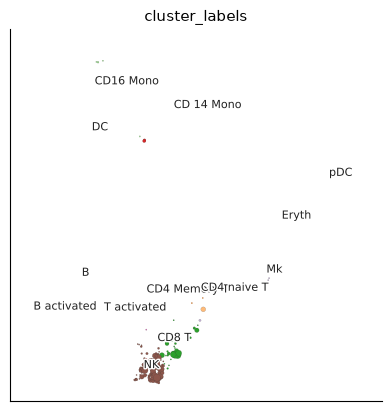

In [6]:
# Here we will generate plots for IFB-B stimulated cells from NK  and CD14 monocyte clusters.

for g, ms in ds_ctrl.get_mapping_score(
    target_name='stim',
    target_groups=ds_stim.cells.fetch('cluster_labels'),
    log_transform=True
):
    
    if g in ['NK', 'CD 14 Mono']:
        print (f"Target cluster {g}")
        splt.embedding(
            ds_ctrl,
            layout_key='RNA_UMAP',
            color_by='cluster_labels',
            point_sizes=ms * 10,
            figsize=(4, 4),
        )

In [7]:
transferred_labels = ds_ctrl.get_target_classes(
    target_name='stim',
    reference_class_group='cluster_labels'
)

transferred_labels

0               CD8 T
1                 pDC
2         CD4 naive T
3                   B
4        CD4 Memory T
             ...     
10106       CD16 Mono
10107              NA
10108               B
10109       CD16 Mono
10110     CD4 naive T
Length: 10111, dtype: object

In [8]:
evidence = ds_ctrl.get_target_label_evidence(
    target_name='stim',
    reference_class_group='cluster_labels',
    threshold_fraction=0.6
)
evidence.head()

,label,voteFraction,voteEntropy,topTwoMargin,featureCoverage,referenceDistancePercentile,isUnknown
0,CD8 T,0.804400,0.494241,0.608801,1.0,0.846844,False
1,pDC,1.000000,-0.000000,1.000000,1.0,0.988430,False
2,CD4 naive T,1.000000,-0.000000,1.000000,1.0,0.882524,False
3,B,1.000000,-0.000000,1.000000,1.0,0.959955,False
4,NA,0.567653,0.683965,0.135306,1.0,0.835427,True


In [9]:
ds_stim.cells.insert(
    'transferred_labels',
    transferred_labels.values,
    overwrite=True
)

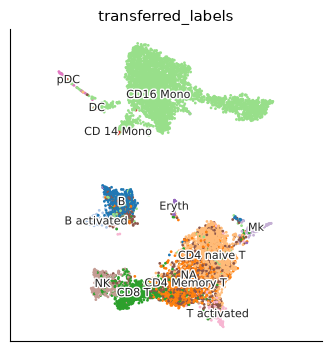

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [10]:
splt.embedding(
    ds_stim,
    layout_key='RNA_UMAP',
    color_by='transferred_labels',
)

In [11]:
import pandas as pd

df = pd.crosstab(
    ds_stim.cells.fetch('cluster_labels'),
    ds_stim.cells.fetch('transferred_labels')
)
df

col_0,B,B activated,CD 14 Mono,CD16 Mono,CD4 Memory T,CD4 naive T,CD8 T,DC,Eryth,Mk,NA,NK,T activated,pDC
row_0,,,,,,,,,,,,,,
B,495,5,0,78,13,2,2,0,0,3,146,0,1,1
B activated,24,138,0,11,2,0,0,0,0,0,28,1,1,0
CD 14 Mono,0,0,5,2527,0,0,0,0,0,0,0,0,0,0
CD16 Mono,0,0,0,956,0,0,0,0,0,0,0,0,0,0
CD4 Memory T,0,0,0,8,668,103,118,0,0,1,398,0,1,0
CD4 naive T,3,0,0,17,335,1600,16,0,0,0,412,2,5,0
CD8 T,0,0,0,1,12,2,588,0,0,0,27,24,1,0
DC,0,0,0,204,1,0,0,8,0,0,1,0,0,0
Eryth,0,0,0,15,9,16,2,0,38,0,3,0,0,0


In [12]:
(100 * df / df.sum(axis=0)).round(1)

col_0,B,B activated,CD 14 Mono,CD16 Mono,CD4 Memory T,CD4 naive T,CD8 T,DC,Eryth,Mk,NA,NK,T activated,pDC
row_0,,,,,,,,,,,,,,
B,94.8,3.5,0.0,2.0,1.2,0.1,0.2,0.0,0.0,2.8,13.0,0.0,0.7,2.8
B activated,4.6,96.5,0.0,0.3,0.2,0.0,0.0,0.0,0.0,0.0,2.5,0.3,0.7,0.0
CD 14 Mono,0.0,0.0,71.4,64.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CD16 Mono,0.0,0.0,0.0,24.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CD4 Memory T,0.0,0.0,0.0,0.2,62.1,5.7,14.3,0.0,0.0,0.9,35.5,0.0,0.7,0.0
CD4 naive T,0.6,0.0,0.0,0.4,31.2,89.2,1.9,0.0,0.0,0.0,36.8,0.5,3.4,0.0
CD8 T,0.0,0.0,0.0,0.0,1.1,0.1,71.1,0.0,0.0,0.0,2.4,6.6,0.7,0.0
DC,0.0,0.0,0.0,5.2,0.1,0.0,0.0,100.0,0.0,0.0,0.1,0.0,0.0,0.0
Eryth,0.0,0.0,0.0,0.4,0.8,0.9,0.2,0.0,97.4,0.0,0.3,0.0,0.0,0.0


In [13]:
ds_ctrl.run_unified_umap(
    target_names=['stim'],
    ini_embed_with='RNA_UMAP',
    target_weight=1,
    use_k=5,
    n_epochs=100
)

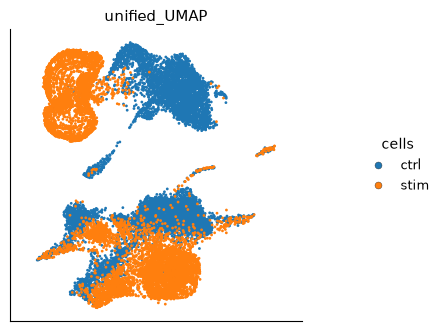

PlotResult(axes=1, tables=1, legends=1, scales=1, owns_figure=True, rendered=True)

In [14]:
splt.unified_embedding(
    ds_ctrl,
    layout_key='unified_UMAP',
    ref_name='ctrl',
)

In [15]:
ds_ctrl.project_mapping_layout(
    target_name='stim',
    reference_layout_key='RNA_UMAP'
)

'RNA/projections/stim/fixed_RNA_UMAP'

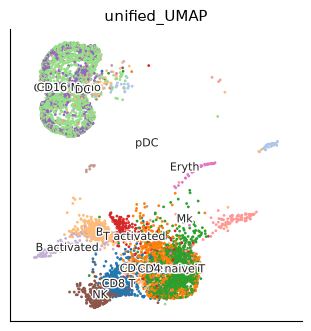

PlotResult(axes=1, tables=1, legends=1, scales=1, owns_figure=True, rendered=True)

In [16]:
splt.unified_embedding(
    ds_ctrl,
    layout_key='unified_UMAP',
    show_target_only=True,
    target_groups=ds_stim.cells.fetch('cluster_labels'),
    legend_loc='on_data',
)

Number of vertices: 18598


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


Maximum iterations: 500


...

Iteration 400: error is 4.27193 (50 iterations in 0.518206 seconds)


Iteration 450: error is 4.26892 (50 iterations in 0.581423 seconds)


Iteration 499: error is 4.28181 (50 iterations in 0.617888 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.964083 sec [21.7145%] |  Repulsive forces: 3.47573 sec [78.2855%]


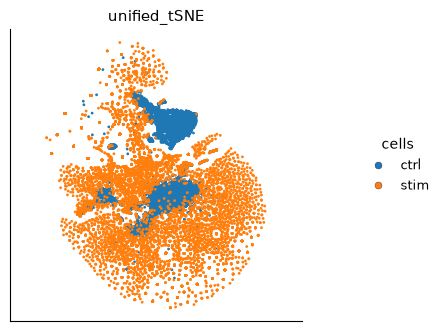

PlotResult(axes=1, tables=1, legends=1, scales=1, owns_figure=True, rendered=True)

In [17]:
ds_ctrl.run_unified_tsne(
    target_names=['stim'],
    ini_embed_with='RNA_UMAP',
    target_weight=1,
    use_k=5,
    max_iter=500
)

splt.unified_embedding(
    ds_ctrl,
    layout_key='unified_tSNE',
    ref_name='ctrl',
)